# Detecting Bots via Mouse Movement Biometrics
## Notebook 3 — Model Evaluation

**Input:** `bot_detector_model.keras`, `X_test.npy`, `y_test.npy`  
**Output:** Confusion matrix, ROC curve, classification report

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)
from tensorflow import keras

print('Imports OK.')

Imports OK.


In [2]:
# ── Load model & test data ───────────────────────────────────────────
model  = keras.models.load_model('bot_detector_model.keras')
X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')

print(f'X_test shape : {X_test.shape}')
print(f'Test samples : {len(y_test)}  (Human: {(y_test==0).sum()}, Bot: {(y_test==1).sum()})')

X_test shape : (517, 200, 4)
Test samples : 517  (Human: 128, Bot: 389)


In [3]:
# ── Predictions ──────────────────────────────────────────────────────
y_prob = model.predict(X_test, verbose=0).flatten()   # P(bot)
y_pred = (y_prob >= 0.5).astype(int)

print('Prediction range:', y_prob.min().round(4), '→', y_prob.max().round(4))

Prediction range: 0.1972 → 0.922


In [4]:
# ── Classification Report ────────────────────────────────────────────
print('\n── Classification Report ──────────────────────')
print(classification_report(y_test, y_pred, target_names=['Human', 'Bot']))


── Classification Report ──────────────────────
              precision    recall  f1-score   support

       Human       0.47      0.98      0.64       128
         Bot       0.99      0.64      0.78       389

    accuracy                           0.73       517
   macro avg       0.73      0.81      0.71       517
weighted avg       0.86      0.73      0.74       517



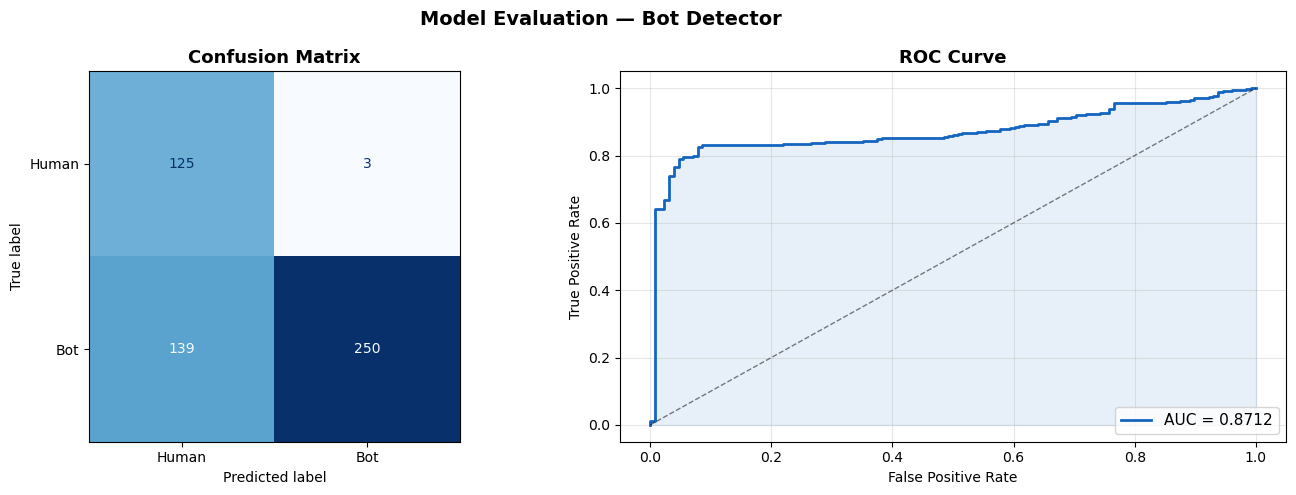

Saved: evaluation_results.png


In [5]:
# ── Confusion Matrix + ROC Curve ─────────────────────────────────────
fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig)

# --- Confusion Matrix ---
ax1 = fig.add_subplot(gs[0, 0])
cm  = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Human', 'Bot'])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# --- ROC Curve ---
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc     = auc(fpr, tpr)
ax2.plot(fpr, tpr, color='#1565C0', lw=2, label=f'AUC = {roc_auc:.4f}')
ax2.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax2.fill_between(fpr, tpr, alpha=0.1, color='#1565C0')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax2.legend(loc='lower right', fontsize=11)
ax2.grid(alpha=0.3)

plt.suptitle('Model Evaluation — Bot Detector', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: evaluation_results.png')

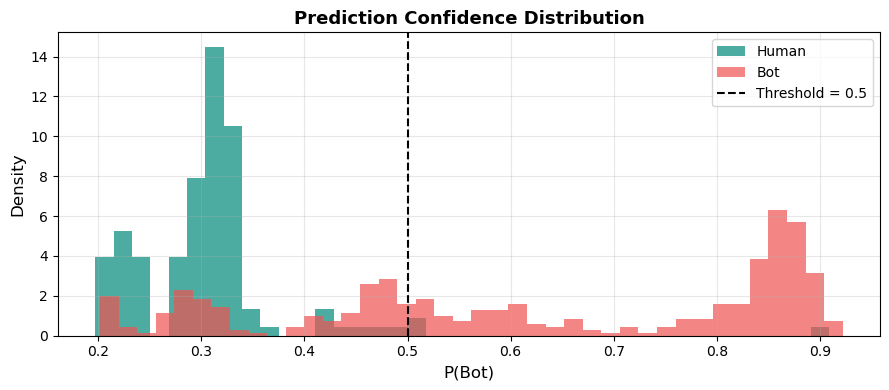

Saved: confidence_distribution.png


In [6]:
# ── Prediction confidence distribution ──────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(y_prob[y_test == 0], bins=40, alpha=0.7, color='#00897B', label='Human', density=True)
ax.hist(y_prob[y_test == 1], bins=40, alpha=0.7, color='#EF5350', label='Bot',   density=True)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold = 0.5')
ax.set_xlabel('P(Bot)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Prediction Confidence Distribution', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confidence_distribution.png')

---
## Summary

| Metric | What it tells you |
|---|---|
| Precision (Bot) | Of sessions flagged as bot, how many actually were |
| Recall (Bot) | Of all actual bots, how many did we catch |
| AUC | Overall discrimination power (1.0 = perfect) |

**Next step:** Run `app.py` (Flask demo) to test with live mouse movement.

In [8]:
import pandas as pd
import requests
import os

# Pick any bot session file
bot_file = r'C:\Users\jayd1\Downloads\nirmamtech\mldl\assgnmnt prjct\delbot-mouse\circles_bot_gan\GAN35_52.txt'

df = pd.read_csv(bot_file, header=None, names=['t','type','x','y'], skiprows=1)
df['type'] = df['type'].str.lower()

events = df.head(200).to_dict(orient='records')
resp = requests.post('http://localhost:5000/predict', json={'events': events})
print(resp.json())

{'bot_pct': 61.1, 'confidence': 61.1, 'demo_mode': False, 'events_used': 52, 'human_pct': 38.9, 'verdict': 'BOT'}


In [2]:
import os
folder = r'C:\Users\jayd1\Downloads\nirmamtech\mldl\assgnmnt prjct\delbot-mouse\circles_bot_pynput'
print(os.listdir(folder)[:5])

['circleHide_1663857155821.txt', 'circleHide_1663857157784.txt', 'circleHide_1663857160235.txt', 'circleHide_1663857161781.txt', 'circleHide_1663857162826.txt']
